# 04 — Serving: the score has a shelf life

A model is scored once; a queue has to stay ranked all day. A lead's stored features never
change, so re-running inference on the same row returns the same number. What *does*
change is its **age** — and notebook 02 showed the model has no evidence past 360 minutes.
Those two facts are the whole design.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, ".")
from pe_style import *
from priority_engine import features, predict
from priority_engine.config import CFG
import joblib

bundle = joblib.load(ARTIFACTS / "notebook_model.joblib")   # written by notebook 03
pipe = bundle["pipeline"]
SUPPORT = CFG["priority"]["decay_support_minutes"]
DECAY = CFG["priority"]["decay_per_hour"]
HORIZON = CFG["priority"]["queue_horizon_hours"]

print(f"support boundary   {SUPPORT} minutes")
print(f"decay beyond it    ×{DECAY}/hour")
print(f"queue horizon      {HORIZON} hours")

support boundary   360 minutes
decay beyond it    ×0.778/hour
queue horizon      24 hours


## 1. Two regimes

Inside 360 minutes the model was fitted on leads of exactly that age, so the scoring job
advances the clock and asks it again. Past the boundary it would be inventing, so its last
answer is kept as an anchor and faded in SQL when the queue is read.

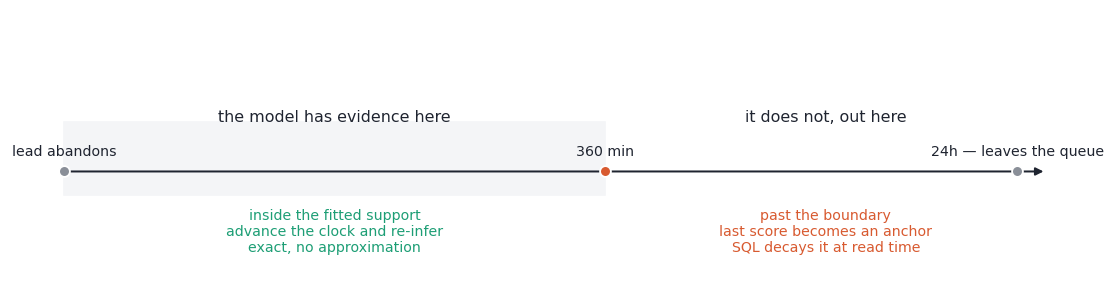

In [2]:
fig, ax = timeline_canvas(rows=1, height_per_row=2.6, width=9.4)
b = 0.55   # where the boundary sits on the drawing

ax.annotate("", xy=(1.0, 0), xytext=(0.0, 0),
            arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.2))
ax.axvspan(0.0, b, ymin=0.34, ymax=0.60, color=SURFACE, zorder=0)
for x, t, c in [(0.0, "lead abandons", MUTED), (b, f"{SUPPORT} min", CORAL),
                (0.97, f"{HORIZON}h — leaves the queue", MUTED)]:
    ax.plot([x], [0], "o", ms=6.5, color=c, zorder=3,
            markeredgecolor="white", markeredgewidth=1.1)
    ax.annotate(t, (x, 0), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8.5, color=INK)

ax.annotate("inside the fitted support\nadvance the clock and re-infer\nexact, no approximation",
            (b / 2, 0), xytext=(0, -22), textcoords="offset points", ha="center",
            va="top", fontsize=8.5, color=TEAL)
ax.annotate("past the boundary\nlast score becomes an anchor\nSQL decays it at read time",
            ((b + 1) / 2, 0), xytext=(0, -22), textcoords="offset points", ha="center",
            va="top", fontsize=8.5, color=CORAL)
ax.annotate("the model has evidence here", (b / 2, 0), xytext=(0, 30),
            textcoords="offset points", ha="center", fontsize=9.5, color=INK, weight="medium")
ax.annotate("it does not, out here", ((b + 1) / 2, 0), xytext=(0, 30),
            textcoords="offset points", ha="center", fontsize=9.5, color=INK, weight="medium")
save(fig, "04_two_regimes");

Two things that are easy to get wrong: the decay applies only to the time **past** the
boundary (the model already priced the age it was handed), and leads past the horizon
**leave** the queue rather than decaying toward zero at the bottom of it.

## 2. How wrong is the decay?

It replaces a model call, so the question is what the model would have said. Below: the
exact answer (re-infer with the clock advanced) against the formula the queue uses.

hours past boundary   decayed    model (pinned)
                 0     3.24%     3.24%
                 1     2.52%     3.24%
                 2     1.96%     3.24%
                 3     1.53%     3.24%
                 4     1.19%     3.24%
                 5     0.92%     3.24%
                 6     0.72%     3.24%
                 7     0.56%     3.24%
                 8     0.44%     3.24%
                 9     0.34%     3.24%
                10     0.26%     3.24%
                11     0.20%     3.24%
                12     0.16%     3.24%


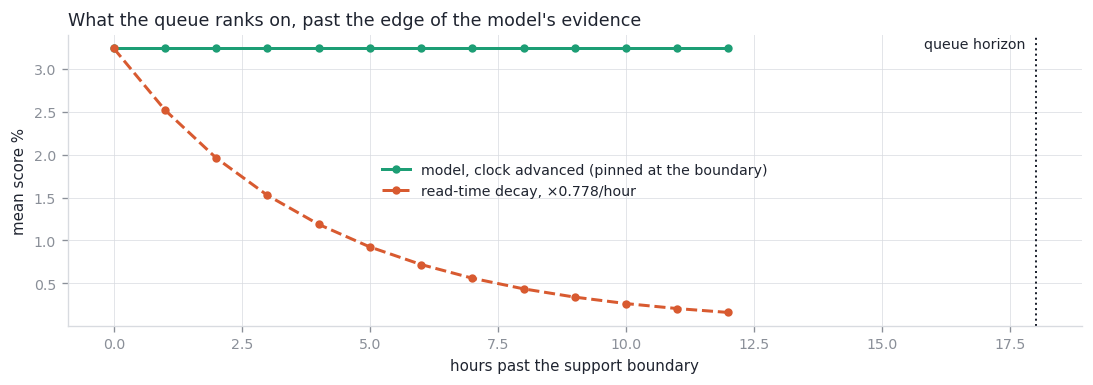

In [3]:
# the holdout cohort, with its full feature rows
test = bundle["test_rows"]
cohort = leads_db().query("lead_id in @test.lead_id").copy()

anchor_age = SUPPORT
extra_hours = np.arange(0, 13)

# exact: what the model says when the clock is advanced to each age
exact = []
for h in extra_hours:
    adv = cohort.copy()
    adv["target_age"] = np.minimum(adv["minutes_since_abandonment"] + anchor_age + h * 60,
                                   SUPPORT)
    adv = predict.advance_clock(adv)
    exact.append(pipe.predict_proba(features.build(adv))[:, 1].mean())

anchor = exact[0]
decayed = [anchor * DECAY ** h for h in extra_hours]

fig, ax = plt.subplots(figsize=(9.2, 3.3))
ax.plot(extra_hours, np.array(exact) * 100, "o-", color=TEAL, lw=1.8, ms=4,
        label="model, clock advanced (pinned at the boundary)")
ax.plot(extra_hours, np.array(decayed) * 100, "o--", color=CORAL, lw=1.8, ms=4,
        label=f"read-time decay, ×{DECAY}/hour")
ax.axvline(HORIZON - SUPPORT / 60, ls=":", lw=1.2, color=INK)
ax.annotate("queue horizon", (HORIZON - SUPPORT / 60, max(exact) * 100),
            xytext=(-6, 0), textcoords="offset points", ha="right",
            fontsize=8.5, color=INK)
ax.set_title("What the queue ranks on, past the edge of the model's evidence")
ax.set_xlabel("hours past the support boundary"); ax.set_ylabel("mean score %")
ax.legend()
save(fig, "04_decay_vs_model")

print("hours past boundary   decayed    model (pinned)")
for h, d, e in zip(extra_hours, decayed, exact):
    print(f"{h:>18}   {d:>7.2%}   {e:>7.2%}")

The flat teal line is the point — past the boundary every input has stopped moving, so the
model repeats the boundary value forever. Re-inference out there is not expensive; it has
nothing left to say.

So the decay does the job the model cannot: a lead abandoned two days ago deserves less
attention than one abandoned six hours ago. It is a **ranking device, not a probability
claim** (agreement with re-inference: mean gap 0.6 pp, Spearman 0.97, 84% overlap in the
top 5%), and the constant is an **upper bound** — with one snapshot per lead, cooling
cannot be separated from the warmer leads having already left.

## 3. Where the queue ends

Carry the anchors forward and see when the best lead left stops being worth a dial. The
floor is **1%**, about a tenth of the base rate — a stated choice, since the data has no
call-cost column to derive one from.

In [4]:
pinned = cohort.copy()
pinned["target_age"] = SUPPORT
anchor_p = pipe.predict_proba(features.build(predict.advance_clock(pinned)))[:, 1]
odds = anchor_p / (1 - anchor_p)

rows = []
for h in (6, 12, 18, 24, 36, 48):
    o = odds * DECAY ** (h - SUPPORT / 60)
    p = o / (1 + o)
    rows.append({"total age": f"{h}h", "best lead": f"{p.max():.2%}",
                 "median lead": f"{np.median(p):.3%}", "above 1%": f"{(p > 0.01).mean():.1%}"})
print(pd.DataFrame(rows).to_string(index=False))

total age best lead median lead above 1%
       6h    22.58%      2.231%    75.2%
      12h     6.08%      0.503%    30.5%
      18h     1.41%      0.112%     0.3%
      24h     0.32%      0.025%     0.0%
      36h     0.02%      0.001%     0.0%
      48h     0.00%      0.000%     0.0%


By ~20 hours the best lead in the queue is under 1%; by 24 hours the whole queue is under
0.5%. Everything between there and the 48 hours this used to run on was dead rows in a
ranked list, diluting the percentile cut-offs that assign P1…P4.

**So the horizon is 24 hours**, and `decay_max_excess_hours` is 18 — the horizon minus the
support window — so the cap never binds on a lead still in the queue. Since the decay is an
upper bound, this is the optimistic end: if leads cool faster, the true horizon is
shorter.

## 5. The whole serving path

| Step | Where | What it does |
|---|---|---|
| every 5 min | `predict.run()` | finds leads whose age has outrun their last score, inside 360 min |
| | `advance_clock()` | moves both clocks — abandonment up, expiry down |
| | model | re-infers; exact for that age |
| | `predictions` | stores the score *and the age it was scored at* |
| on read | `v_current_priority` | decays the anchor past the boundary, drops leads past 24h |
| every run | `monitoring_snapshots` | records the score distribution, so drift is visible |

Storing `scored_at_age_minutes` next to each prediction is what makes this self-limiting:
it is the field that tells the next run whether a lead still needs work.